<a href="https://colab.research.google.com/github/aleksaveger-bot/AlexaVegera/blob/main/%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(0)

# Исходные данные
estate = np.random.choice(['квартира', 'апартаменты', 'частный дом'], size=30, replace=True)
type_of_estate = ['первичное', 'вторичное'] * 15
state_of_renovation = ['евроремонт', 'косметический', 'чистовая отделка', 'черновая отделка', 'без отделки'] * 6
location = ['Milan', 'Rome', 'Napolli', 'Rimini', 'Venice'] * 6
number_of_rooms = np.random.randint(1, 6, size=30)
distance_up_to_center = np.round(np.random.uniform(1, 10, 30), 2)
date_of_building_house = pd.to_datetime(pd.date_range(start='1998-01-01', end='2022-12-31', periods=30))

# Площадь: зависит от числа комнат
square = np.array([
    np.random.randint(30 + (rooms - 1) * 8, 45 + (rooms - 1) * 9)
    for rooms in number_of_rooms
])

# Базовые данные
data = {
    'estate': estate,
    'type_of_estate': type_of_estate,
    'state_of_renovation': state_of_renovation,
    'location': location,
    'number_of_rooms': number_of_rooms,
    'distance_up_to_center': distance_up_to_center,
    'date_of_building_house': date_of_building_house,
    'square': square
}

df = pd.DataFrame(data)

# ---------------------------------------------
# Настройки модели
# ---------------------------------------------

# Базовая цена за комнату (влияет на расчётную цену)
base_per_room = {
    'Milan': 42000,
    'Rome': 47000,
    'Napolli': 27000,
    'Rimini': 22000,
    'Venice': 40000
}

# Минимальная цена в регионе (рыночный порог)
min_price_by_location = {
    'Milan': 40000,
    'Rome': 45000,
    'Napolli': 20000,
    'Rimini': 18000,
    'Venice': 38000
}

# Коэффициенты
renovation_bonus = {
    'евроремонт': 1.3,
    'чистовая отделка': 1.1,
    'косметический': 1.0,
    'черновая отделка': 0.8,
    'без отделки': 0.6
}

type_discount = {
    'апартаменты': 0.8,
    'квартира': 1.0,
    'частный дом': 1.0
}

# Функция расчёта финальной цены
def generate_price(row):
    loc = row['location']
    dist = row['distance_up_to_center']
    rooms = row['number_of_rooms']
    renovation = row['state_of_renovation']
    estate_type = row['estate']
    square = row['square']

    # 1. Базовая цена с учётом площади
    base_price_per_room = base_per_room.get(loc, 35000)
    base_price = base_price_per_room * rooms * (square / 40)

    # 2. Эффект расстояния
    distance_effect = np.exp(-0.25 * dist)

    # 3. Множители
    renov_mult = renovation_bonus.get(renovation, 1.0)
    type_mult = type_discount.get(estate_type, 1.0)
    noise = np.random.uniform(0.9, 1.1)

    # 4. Расчётная цена
    calculated_price = base_price * distance_effect * renov_mult * type_mult * noise

    # 5. Применяем минимальную цену по региону
    min_price = min_price_by_location.get(loc, 20000)
    final_price = max(calculated_price, min_price)  # Цена не может быть ниже регионального минимума

    return round(final_price, 2)

# Применяем функцию
df['price'] = df.apply(generate_price, axis=1)

# Меняем формат даты на ДД.ММ.ГГГГ
df['date_of_building_house'] = df['date_of_building_house'].dt.strftime('%d.%m.%Y')

# Выводим результат
display(df[['location', 'estate','state_of_renovation', 'number_of_rooms','square', 'distance_up_to_center','price','date_of_building_house']])

,location,estate,state_of_renovation,number_of_rooms,square,distance_up_to_center,price,date_of_building_house
0,Milan,квартира,евроремонт,4,63,7.00,56962.12,01.01.1998
1,Rome,апартаменты,косметический,4,54,7.04,45000.00,11.11.1998
2,Napolli,квартира,чистовая отделка,4,64,2.89,93265.84,22.09.1999
3,Rimini,апартаменты,черновая отделка,1,32,2.16,18000.00,02.08.2000
4,Venice,апартаменты,без отделки,2,49,3.84,38000.00,13.06.2001
5,Milan,частный дом,евроремонт,2,48,4.27,41874.05,24.04.2002
6,Rome,квартира,косметический,2,53,6.13,45000.00,04.03.2003
7,Napolli,частный дом,чистовая отделка,1,37,4.95,20000.00,13.01.2004
8,Rimini,квартира,черновая отделка,3,48,9.90,18000.00,23.11.2004
9,Venice,квартира,без отделки,5,64,1.92,117221.25,04.10.2005


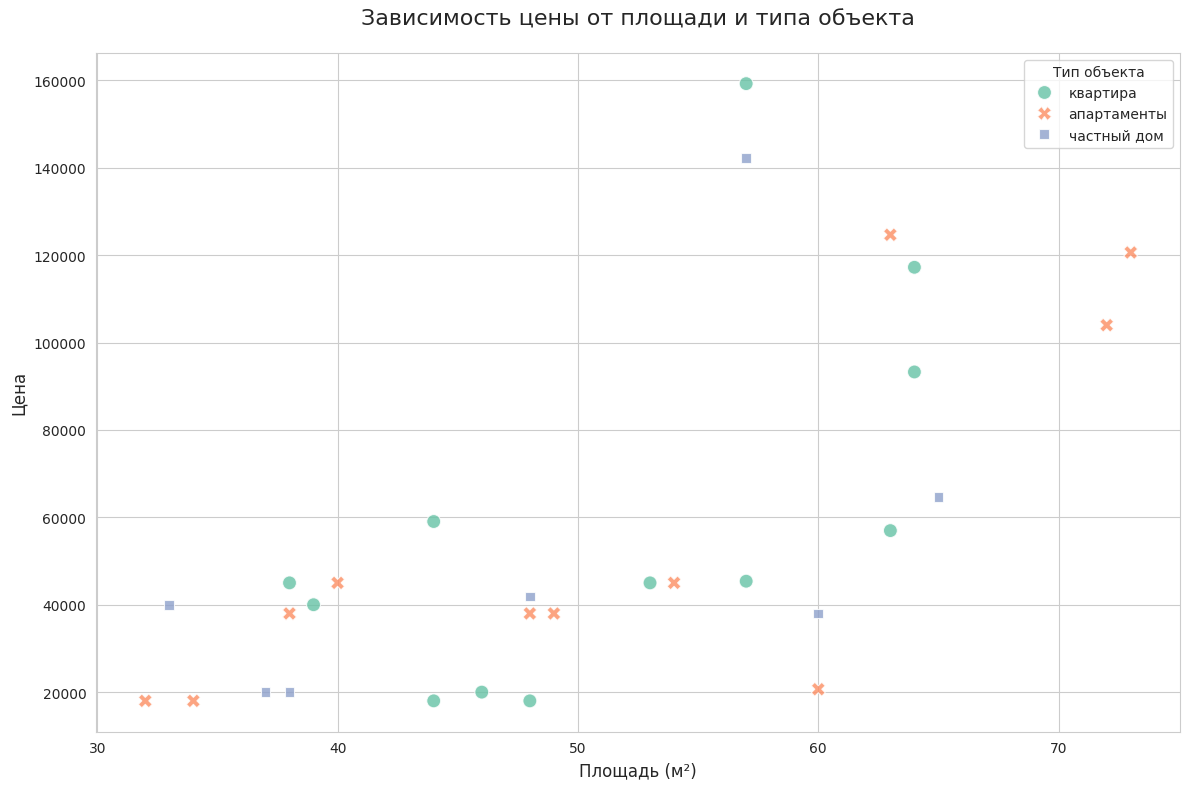


Выводы:
На графике видна положительная линейная зависимость между площадью объекта недвижимости (square) и ценой (price).
Это подтверждает, что цена зависит от типа объекта и площади, как и было задумано при создании датасета.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Зависимость ===
# Признак 'price' зависит от 'square'
# Покажем это на графике

# Визуализация зависимости цены от площади (square)
# Устанавливаем стиль
sns.set_style('whitegrid')

# График: цена vs площадь, разделённый по регионам, с цветом по типу объекта
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='square',                    # Площадь по оси X
    y='price',                   # Цена по оси Y
    hue='estate',                # Цвет точек — тип недвижимости
    style='estate',              # Разные маркеры для типов
    palette='Set2',
    s=100,                       # Размер точек
    alpha=0.8
)

# Оформление
plt.title('Зависимость цены от площади и типа объекта', fontsize=16, pad=20)
plt.xlabel('Площадь (м²)', fontsize=12)
plt.ylabel('Цена', fontsize=12)
plt.legend(title='Тип объекта', fontsize=10)
plt.tight_layout()
plt.show()

# === Выводы ===
print("\nВыводы:")
print("На графике видна положительная линейная зависимость между площадью объекта недвижимости (square) и ценой (price).")
print("Это подтверждает, что цена зависит от типа объекта и площади, как и было задумано при создании датасета.")